# 01 — Causal EDA
Treatment/control balance, overlap feasibility, churn heterogeneity.

In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from feature_engineering import build_features, FEATURE_COLS, EXPECTED_ICD

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11})
sns.set_style('whitegrid')


In [2]:
df = build_features('train')
print(f"Shape: {df.shape}")
print(f"Churn rate overall: {df['churn'].mean():.4f}")
print(f"Outreach rate: {df['outreach'].mean():.4f}")
print()
ct = df.groupby('outreach')['churn'].agg(['mean','count']).rename(columns={'mean':'churn_rate','count':'n'})
ct['churn_pct'] = (ct['churn_rate']*100).round(2)
print(ct)
print(f"\nATT (naive): {ct.loc[1,'churn_rate'] - ct.loc[0,'churn_rate']:.4f}")


Shape: (10000, 17)
Churn rate overall: 0.2021
Outreach rate: 0.3984

          churn_rate     n  churn_pct
outreach                             
0             0.2074  6016    20.7400
1             0.1940  3984    19.4000

ATT (naive): -0.0134


In [3]:
# Standardized Mean Differences
rows = []
for col in FEATURE_COLS:
    t = df[df['outreach']==1][col]
    c = df[df['outreach']==0][col]
    smd = (t.mean() - c.mean()) / np.sqrt((t.std()**2 + c.std()**2)/2 + 1e-9)
    rows.append({'feature': col, 'treated_mean': t.mean(), 'control_mean': c.mean(), 'SMD': smd})
smd_df = pd.DataFrame(rows).sort_values('SMD', key=abs, ascending=False)
print(smd_df.to_string(index=False))


              feature  treated_mean  control_mean     SMD
         app_sessions        8.7196       10.4804 -0.5043
  app_sessions_last7d        4.3660        5.2467 -0.3756
       days_since_app        1.2575        0.9427  0.1462
          tenure_days      296.5331      308.2877 -0.0785
 health_content_ratio        0.3620        0.3699 -0.0542
         total_visits       26.1775       25.7728  0.0235
            icd_Z71_3        0.5959        0.5854  0.0212
        wellco_visits       10.0592       10.2101 -0.0195
    days_since_wellco        3.4433        3.6313 -0.0133
            icd_E11_9        0.5853        0.5898 -0.0090
 unexpected_icd_count        2.8911        2.8838  0.0054
              icd_I10        0.5871        0.5898 -0.0054
unique_wellco_domains        3.2477        3.2518 -0.0040
   expected_icd_count        1.7683        1.7650  0.0039


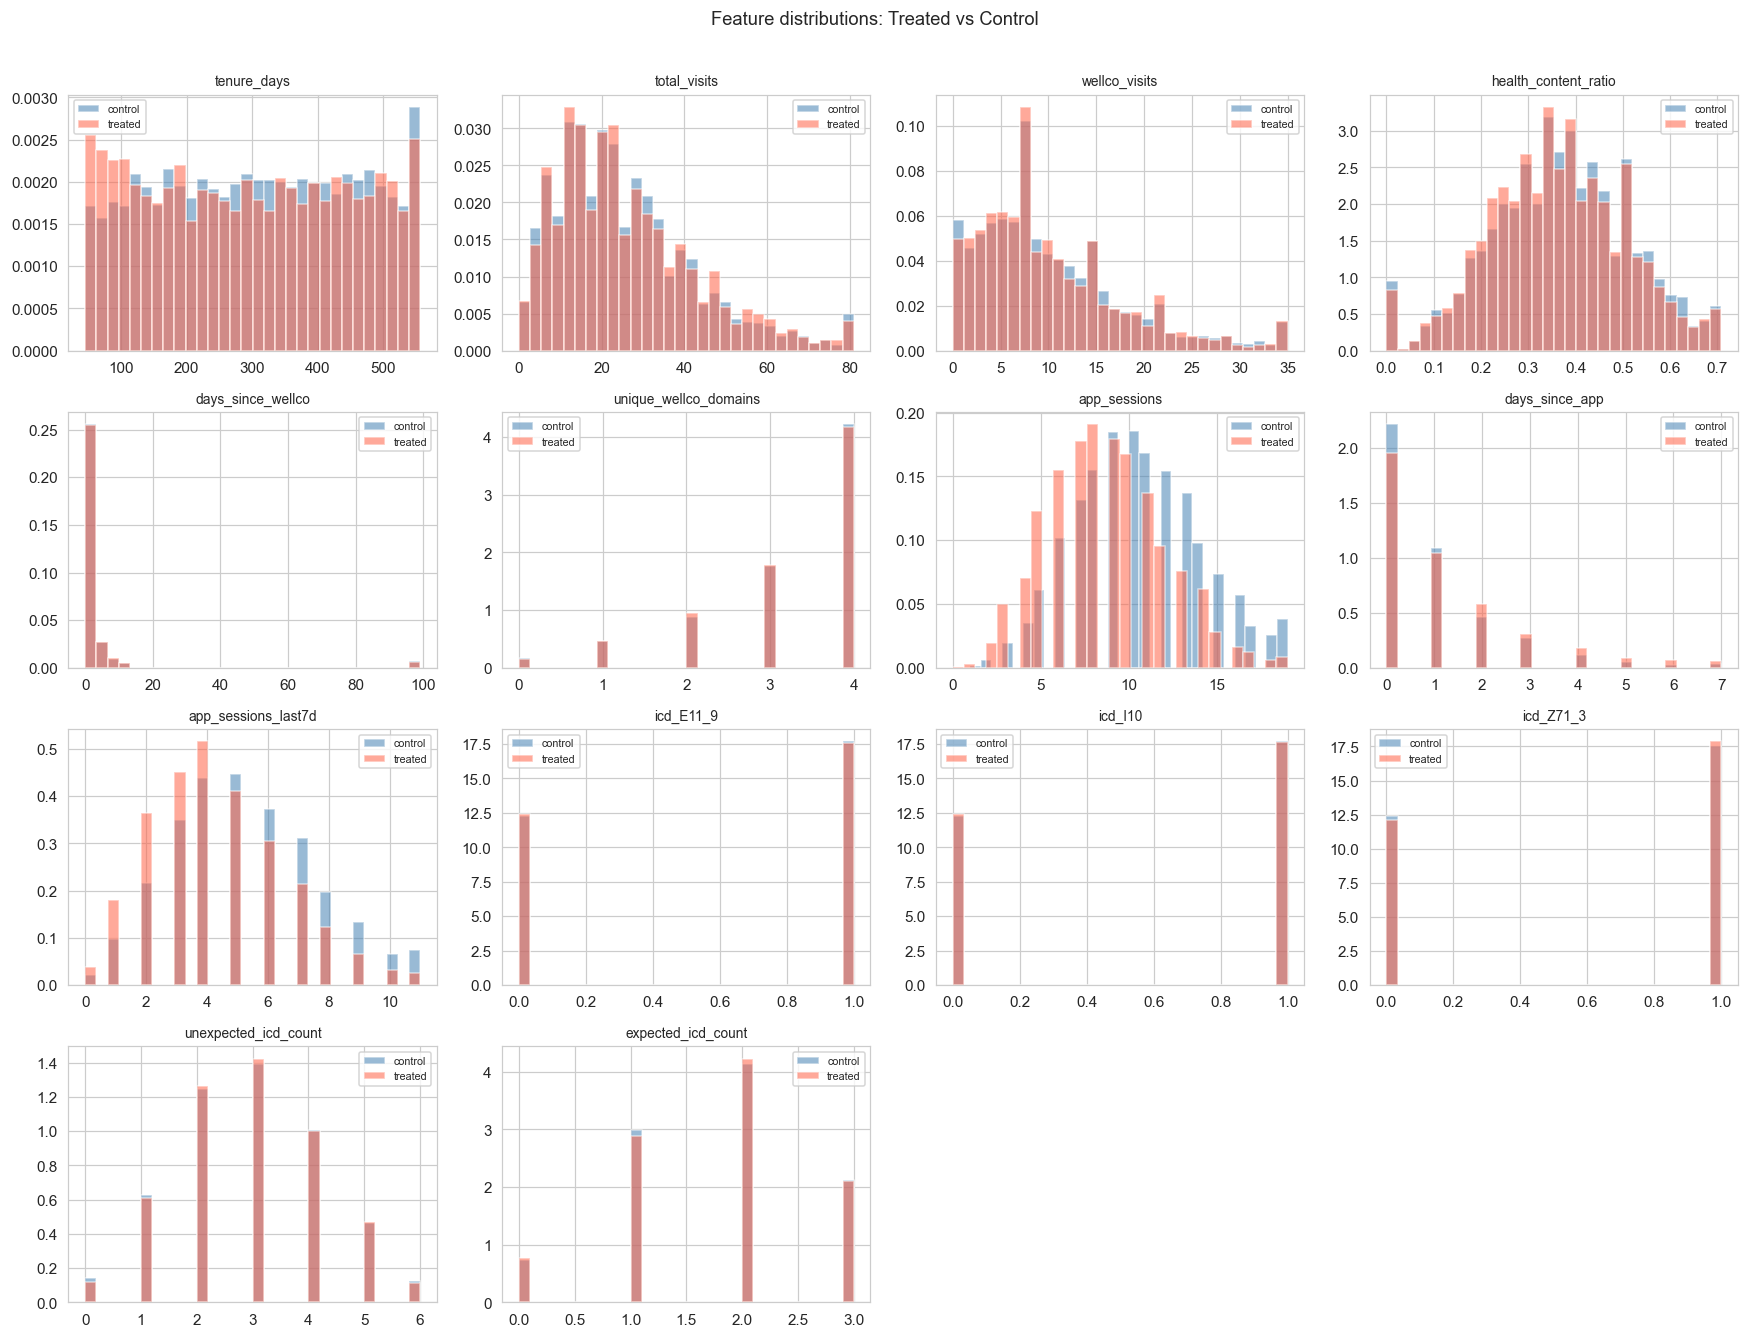

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    for trt, label, color in [(0,'control','steelblue'),(1,'treated','tomato')]:
        vals = df[df['outreach']==trt][col].clip(
            upper=df[col].quantile(0.99)
        )
        ax.hist(vals, bins=30, alpha=0.55, density=True, label=label, color=color)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Feature distributions: Treated vs Control', y=1.01)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', bbox_inches='tight')
plt.show()


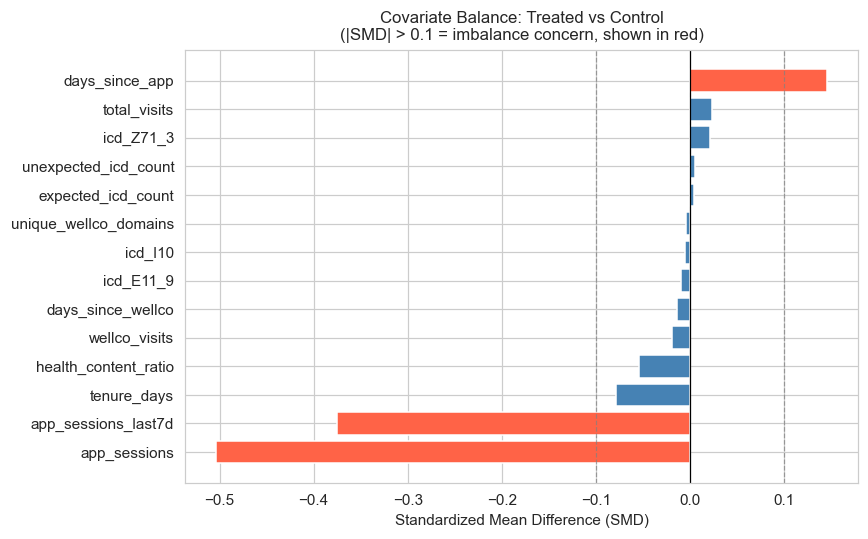

In [5]:
# SMD lollipop
fig, ax = plt.subplots(figsize=(8, 5))
smd_df_plot = smd_df.sort_values('SMD')
colors = ['tomato' if abs(s) > 0.1 else 'steelblue' for s in smd_df_plot['SMD']]
ax.barh(smd_df_plot['feature'], smd_df_plot['SMD'], color=colors)
ax.axvline(0.1, ls='--', color='gray', lw=0.8, alpha=0.7)
ax.axvline(-0.1, ls='--', color='gray', lw=0.8, alpha=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Standardized Mean Difference (SMD)')
ax.set_title('Covariate Balance: Treated vs Control\n(|SMD| > 0.1 = imbalance concern, shown in red)')
plt.tight_layout()
plt.savefig('eda_smd.png', bbox_inches='tight')
plt.show()


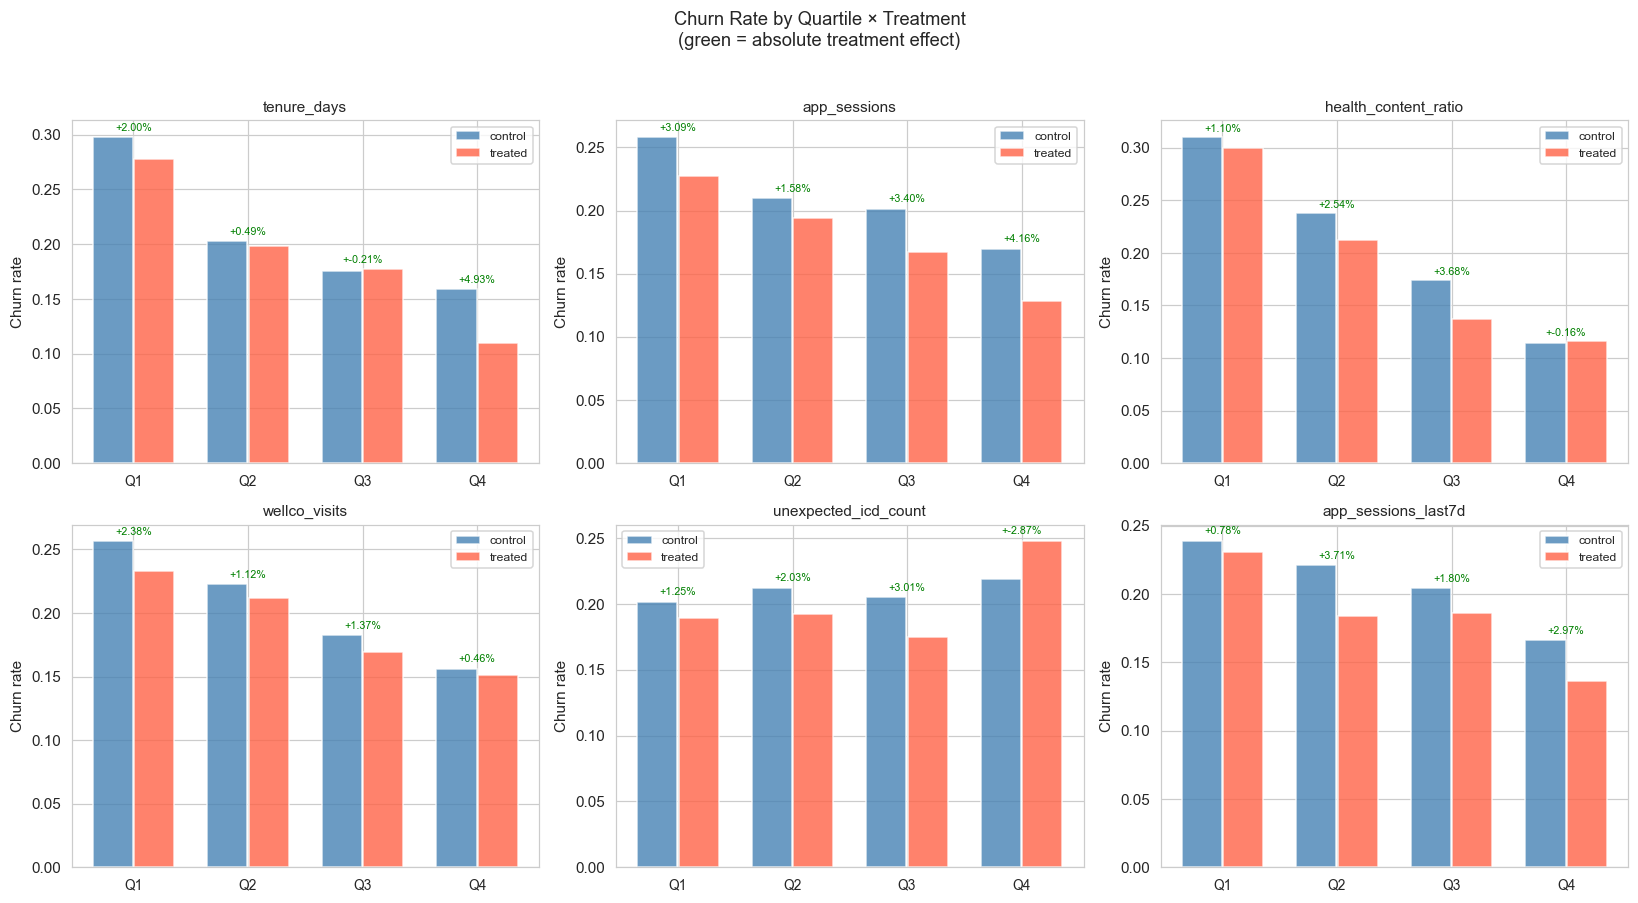

In [6]:
# Churn rates by feature quartile × treatment — heterogeneity check
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
key_features = ['tenure_days', 'app_sessions', 'health_content_ratio',
                'wellco_visits', 'unexpected_icd_count', 'app_sessions_last7d']
for i, feat in enumerate(key_features):
    ax = axes[i]
    try:
        q_col = pd.qcut(df[feat], 4, labels=['Q1','Q2','Q3','Q4'], duplicates='drop')
    except Exception:
        q_col = pd.cut(df[feat], 4, labels=['Q1','Q2','Q3','Q4'])
    df['q'] = q_col
    het = df.groupby(['q','outreach'], observed=True)['churn'].mean().unstack()
    if 0 in het.columns and 1 in het.columns:
        het['uplift'] = het[0] - het[1]
        x = range(len(het))
        ax.bar([xi-0.18 for xi in x], het[0], width=0.35, label='control', color='steelblue', alpha=0.8)
        ax.bar([xi+0.18 for xi in x], het[1], width=0.35, label='treated', color='tomato', alpha=0.8)
        ax.set_xticks(list(x))
        ax.set_xticklabels(het.index, fontsize=9)
        ax.set_title(feat, fontsize=10)
        ax.set_ylabel('Churn rate')
        ax.legend(fontsize=8)
        for xi, (_, row) in zip(x, het.iterrows()):
            ax.text(xi, max(row[0], row[1]) + 0.005, f"+{row['uplift']:.2%}", ha='center', fontsize=7, color='green')
plt.suptitle('Churn Rate by Quartile × Treatment\n(green = absolute treatment effect)', y=1.02)
plt.tight_layout()
plt.savefig('eda_heterogeneity.png', bbox_inches='tight')
plt.show()
df.drop(columns=['q'], inplace=True, errors='ignore')


In [7]:
# Summary statistics
print("=== EDA Summary ===")
print(f"Overall churn: {df['churn'].mean():.4f}")
print(f"Treated churn: {df[df['outreach']==1]['churn'].mean():.4f}")
print(f"Control churn: {df[df['outreach']==0]['churn'].mean():.4f}")
print(f"Naive ATE: {df[df['outreach']==1]['churn'].mean() - df[df['outreach']==0]['churn'].mean():.4f}")
print()
print("Largest imbalances (|SMD| > 0.1):")
print(smd_df[smd_df['SMD'].abs() > 0.1][['feature','SMD']].to_string(index=False))
print()
print("Heterogeneity visible in: tenure_days, app_sessions (higher engagement = less benefit)")


=== EDA Summary ===
Overall churn: 0.2021
Treated churn: 0.1940
Control churn: 0.2074
Naive ATE: -0.0134

Largest imbalances (|SMD| > 0.1):
            feature     SMD
       app_sessions -0.5043
app_sessions_last7d -0.3756
     days_since_app  0.1462

Heterogeneity visible in: tenure_days, app_sessions (higher engagement = less benefit)
